In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [20]:
N = 200
H = 2
EPOCHS = 300
LR = 0.01

In [21]:
# generate 2D Gaussian Data x= input, mu= mean, C = covariance matrix
def gaussian_2d(x, mean, C):
    difference = x - mean
    inv_C = np.linalg.inv(C)
    exponent = -0.5 * np.sum(difference @ inv_C * difference, axis=1)
    return np.exp(exponent)

In [22]:
def generate_data(N):
    x = np.random.uniform(-4, 4, (N, 2))
    mean = np.array([0, 0])
    C = np.array([[3.0, 0.5], [0.5, 2.0]])
    y = gaussian_2d(x, mean, C)
    return x, y.reshape(-1, 1)

In [23]:
# prepare datasets
X_train,y_train = generate_data(N)
X_test, y_test = generate_data(100)

In [24]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [25]:
def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

In [26]:
class MLP:
    def __init__(self, input_size, hidden_size, lr=0.01):
        self.lr = lr

        self.w1 = np.random.randn(hidden_size, input_size)  * 0.1
        self.b1 = np.zeros((hidden_size, 1))

        self.w2 = np.random.randn(1, hidden_size)  * 0.1
        self.b2 = np.zeros((1, 1))

    def forward(self, x):
        self.x = x.reshape(-1, 1)

        self.z1 = self.w1 @ self.x + self.b1
        self.out1 = sigmoid(self.z1)

        self.z2 = self.w2 @ self.out1 + self.b2
        self.y_pred = self.z2   # linear activation

        return self.y_pred
    
    def backward(self, y_true):
        y_true = y_true.reshape(1,1)

        # output layer error
        dz2 = self.y_pred - y_true
        dw2 = dz2 @ self.out1.T
        db2 = dz2

        # Hidden layer error
        dz1 = (self.w2.T @ dz2) * sigmoid_derivative(self.z1)
        dw1 = dz1 @ self.x.T
        db1 = dz1

        # update weights
        self.w2 = self.w2 - self.lr * dw2
        self.b2 = self.b2 - self.lr * db2

        self.w1 = self.w1 - self.lr * dw1
        self.b1 = self.b1 - self.lr * db1


In [33]:
def train(model, X_train, y_train, epochs):
    losses = []

    for epoch in range(epochs):
        total_loss = 0

        for x_i, y_i in zip(X_train, y_train):
            y_pred = model.forward(x_i)

            loss = 0.5 * (y_pred - y_i)**2
            total_loss = total_loss + loss.item()

            model.backward(y_i)

        losses.append(total_loss / len(X_train))

        if epoch % 50 == 0:
            print(f"Epoch {epoch}, Loss: {losses[-1]}")

    return losses

In [34]:
def predict(model, X):
    preds = []

    for x in X:
        y_pred = model.forward(x)
        preds.append(y_pred[0][0])

    return np.array(preds)

In [35]:
mlp = MLP(input_size=2, hidden_size=H, lr=LR)

In [36]:
losses = train(model=mlp, X_train=X_train, y_train=y_train, epochs=EPOCHS)

Epoch 0, Loss: 0.042067095071584765
Epoch 50, Loss: 0.03510888770942694
Epoch 100, Loss: 0.03510072342688558
Epoch 150, Loss: 0.035095860448556386
Epoch 200, Loss: 0.0350925510507079
Epoch 250, Loss: 0.035090300702137124


In [37]:
y_pred = predict(model=mlp, X=X_test)

In [39]:
mse = np.mean((y_pred - y_test.flatten())**2)
print("Test MSE:", mse)

Test MSE: 0.06010350412868232


# Analyze

In [ ]:
# Epochs (E*)
def experiment_epochs():

    epoch_list = [50, 100, 200, 300, 500]
    test_errors = []

    for E in epoch_list:

        mlp = MLP(input_size=2, hidden_size=5, lr=0.01)

        train(mlp, X_train, y_train, epochs=E)

        y_pred = predict(mlp, X_test)
        mse = np.mean((y_pred - y_test.flatten())**2)

        test_errors.append(mse)

    plt.figure()
    plt.plot(epoch_list, test_errors, marker='o')
    plt.xlabel('Epochs')
    plt.ylabel('Test MSE')
    plt.title('Effect of Epochs (E)')
    plt.show()

    return epoch_list, test_errors

In [ ]:
# Training Size (N*)
def experiment_N():

    N_list = [50, 100, 200, 500]
    test_errors = []

    for N in N_list:

        X_train, y_train = generate_data(N)

        mlp = MLP(input_size=2, hidden_size=5, lr=0.01)

        train(mlp, X_train, y_train, epochs=200)  # use E*

        y_pred = predict(mlp, X_test)
        mse = np.mean((y_pred - y_test.flatten())**2)

        test_errors.append(mse)

    plt.figure()
    plt.plot(N_list, test_errors, marker='o')
    plt.xlabel('Training Size (N)')
    plt.ylabel('Test MSE')
    plt.title('Effect of Training Size (N)')
    plt.show()

    return N_list, test_errors

In [ ]:
#Hidden Nodes (H*)
def experiment_H():

    H_list = [2, 5, 10, 20]
    test_errors = []

    for H in H_list:

        mlp = MLP(input_size=2, hidden_size=H, lr=0.01)

        train(mlp, X_train, y_train, epochs=200)  # use E*

        y_pred = predict(mlp, X_test)
        mse = np.mean((y_pred - y_test.flatten())**2)

        test_errors.append(mse)

    plt.figure()
    plt.plot(H_list, test_errors, marker='o')
    plt.xlabel('Hidden Nodes (H)')
    plt.ylabel('Test MSE')
    plt.title('Effect of Hidden Nodes (H)')
    plt.show()

    return H_list, test_errors

Epoch 0, Loss: 0.04317259319357323
Epoch 0, Loss: 0.041334827643613584
Epoch 50, Loss: 0.03517597956153941
Epoch 0, Loss: 0.03840583049282113
Epoch 50, Loss: 0.03518757157628809
Epoch 100, Loss: 0.03518204525760239
Epoch 150, Loss: 0.035178648058784706
Epoch 0, Loss: 0.04229872842126534
Epoch 50, Loss: 0.03517673213673132
Epoch 100, Loss: 0.03517304605423036
Epoch 150, Loss: 0.035171359408314624
Epoch 200, Loss: 0.03516909738603048
Epoch 250, Loss: 0.03516566480005281
Epoch 0, Loss: 0.04517073707691703
Epoch 50, Loss: 0.035168793720761767
Epoch 100, Loss: 0.0351663758514176
Epoch 150, Loss: 0.03516574208452186
Epoch 200, Loss: 0.035165009397144106
Epoch 250, Loss: 0.03516409002706815
Epoch 300, Loss: 0.03516291357664182
Epoch 350, Loss: 0.035161386136093965
Epoch 400, Loss: 0.03515937862775213
Epoch 450, Loss: 0.035156700739199326


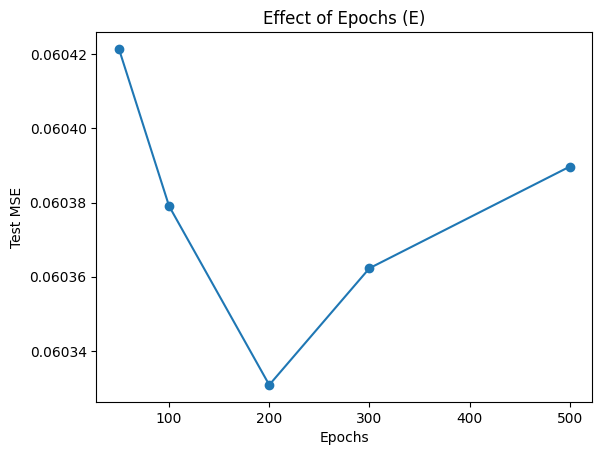

([50, 100, 200, 300, 500],
 [np.float64(0.060421446945794786),
  np.float64(0.06037906456276623),
  np.float64(0.06033080349968244),
  np.float64(0.06036228797278879),
  np.float64(0.060389712199654444)])

In [43]:
experiment_epochs()

Epoch 0, Loss: 0.07974371962388802
Epoch 50, Loss: 0.04970802616146854
Epoch 100, Loss: 0.04960941349512418
Epoch 150, Loss: 0.0495495439821519
Epoch 0, Loss: 0.04310138303540862
Epoch 50, Loss: 0.03604460342204505
Epoch 100, Loss: 0.035992486425719054
Epoch 150, Loss: 0.03598355066385722
Epoch 0, Loss: 0.03568811889112109
Epoch 50, Loss: 0.028996066088635544
Epoch 100, Loss: 0.02898909699877468
Epoch 150, Loss: 0.02898775049049136
Epoch 0, Loss: 0.03471268712125836
Epoch 50, Loss: 0.03287031664897329
Epoch 100, Loss: 0.03286647785895889
Epoch 150, Loss: 0.03285875864234744


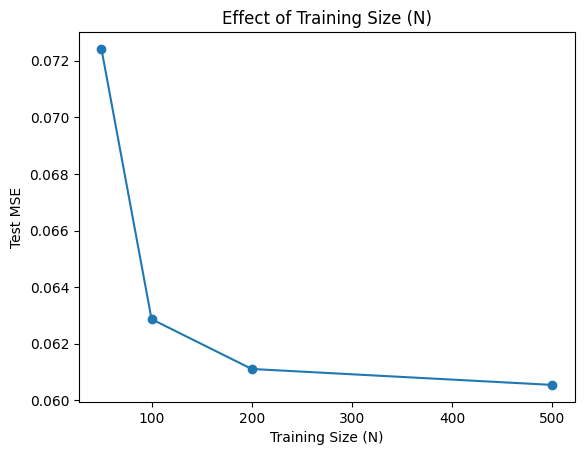

([50, 100, 200, 500],
 [np.float64(0.07241762190579609),
  np.float64(0.06286825932526656),
  np.float64(0.06110768234098015),
  np.float64(0.06054393688711488)])

In [44]:
experiment_N()

Epoch 0, Loss: 0.036121445972171984
Epoch 50, Loss: 0.03509030619813581
Epoch 100, Loss: 0.035090953256344426
Epoch 150, Loss: 0.03509094909962141
Epoch 0, Loss: 0.041151283857287
Epoch 50, Loss: 0.035165115632816324
Epoch 100, Loss: 0.03516495698758717
Epoch 150, Loss: 0.035165017992237944
Epoch 0, Loss: 0.03837387685550273
Epoch 50, Loss: 0.03531649741982177
Epoch 100, Loss: 0.035306908674313894
Epoch 150, Loss: 0.03529306806824237
Epoch 0, Loss: 0.04541930130194937
Epoch 50, Loss: 0.03569688976622202
Epoch 100, Loss: 0.03568614757411737
Epoch 150, Loss: 0.0356708155135495


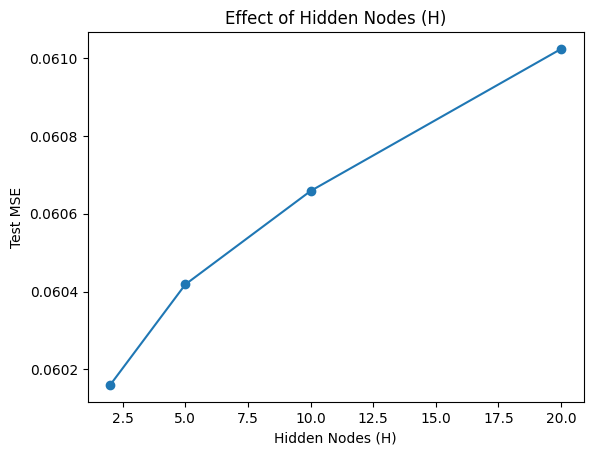

([2, 5, 10, 20],
 [np.float64(0.06015994920512711),
  np.float64(0.060418329784943554),
  np.float64(0.060658577801359165),
  np.float64(0.06102380474549005)])

In [45]:
experiment_H()